# Carbon Mapper raster wrappers

Two thin wrappers over `RasterioReader` for Carbon Mapper's
**GeoTIFF** assets:

- **`CMImageRaster`** — L2B scene rasters: `cmf` (matched-filter
  CH₄ retrieval, ppm·m), `rgb`, `uncertainty`, `artifact-mask`.
  Composes the CH₄ collection (`l2b-ch4-mfa-v3a`) and the sibling
  RGB collection (`l2b-rgb-v3a`) on the same UTM grid.
- **`CMPlumeRaster`** — L3A per-plume mask: `plume_tif` only, an
  RGBA GeoTIFF whose **band 4 alpha** is the binary plume mask.
  `polygon()` vectorises the mask (or uses the optional
  `ime_outline_geojson` sidecar when present) to produce the
  authoritative plume outline.

**Out of scope** — intentionally not wrapped:

- PNG assets (`rgb_png` / `plume_png` / `plume_rgb_png`) are
  un-georeferenced and not COGs.
- Per-plume `con_tif` duplicates a circular crop of the parent
  scene's `cmf`. Crop `CMImageRaster.cmf` to the plume polygon to
  get the same data without the duplicate asset.

Lazy by design: touching `.cmf` opens the GeoTIFF via
`RasterioReader` (no data read); `read_polygon` returns a windowed
reader; only `.load()` materialises a `GeoTensor`. See the
[GeoReader concepts page](../modules/read_module.md) for the
abstract contract these wrappers satisfy.

The companion notebook
[`api_explore.ipynb`](api_explore.ipynb) covers the typed query
layer that produces the `CMRawPlume` / `CMTileItem` instances
consumed below.


## Install

```
pip install 'georeader-spaceml[carbonmapper]'
```

The raster wrappers don't add any new dependencies on top of the
base `[carbonmapper]` extra — they go through `rasterio` /
`georeader.RasterioReader` for the actual I/O.


## Setup

Authentication is identical to the
[`api_explore.ipynb`](api_explore.ipynb#authentication) flow —
`CarbonMapperConfig.load()` resolves a Bearer token from env or
config file. Carbon Mapper's STAC asset URLs are also gated by the
same token, so we push it into GDAL's curl session here so
`RasterioReader` (which goes through rasterio → GDAL → libcurl) can
read them directly without a manual download step.

In [1]:
import os

from georeader.readers.carbonmapper import (
    CM_L2B_BANDS,
    CMImageRaster,
    CMPlumeRaster,
    CarbonMapperConfig,
    DEFAULT_L2B_RGB_COLLECTION,
    api_queries,
)

TOKEN = CarbonMapperConfig.load().refresh_access_token()

# RasterioReader streams over GDAL/libcurl. Push the token in once.
os.environ["GDAL_HTTP_HEADERS"] = f"Authorization: Bearer {TOKEN}"
os.environ["CPL_VSIL_CURL_ALLOWED_EXTENSIONS"] = ".tif,.TIF"

PLUME_ID = "tan20251212t185057c20s4001-E"
SCENE_ID = PLUME_ID.rsplit("-", 1)[0]
print(f"plume = {PLUME_ID}")
print(f"scene = {SCENE_ID}")
print(f"L2B bands: {CM_L2B_BANDS}")

plume = tan20251212t185057c20s4001-E
scene = tan20251212t185057c20s4001
L2B bands: ('cmf', 'rgb', 'uncertainty', 'artifact-mask')


## 1 · `CMImageRaster` — L2B scene

Carbon Mapper publishes L2B across **two sibling STAC collections**
that share `scene_id` and the same UTM pixel grid:

| Collection | Asset(s) |
|---|---|
| `l2b-ch4-mfa-v3a` | `cmf` · `uncertainty` · `artifact-mask` |
| `l2b-rgb-v3a` (= `DEFAULT_L2B_RGB_COLLECTION`) | `rgb` |

`CMImageRaster.from_cm_tile_item(ch4_item)` covers the CH4 side;
chain `.with_rgb(rgb_item)` to merge the RGB sibling into the same
wrapper.

In [2]:
# Two STAC items per L2B scene — fetch each then compose.
ch4_tile = api_queries.get_tile(TOKEN, SCENE_ID)
rgb_tile = api_queries.get_tile(
    TOKEN, SCENE_ID, collection=DEFAULT_L2B_RGB_COLLECTION,
)

ir = CMImageRaster.from_cm_tile_item(ch4_tile).with_rgb(rgb_tile)
print(f"scene_id       : {ir.scene_id}")
print(f"available bands: {sorted(ir.asset_paths)}")

scene_id       : tan20251212t185057c20s4001
available bands: ['artifact-mask', 'cmf', 'rgb', 'uncertainty']


### Lazy band access + scene metadata

Touching `.cmf` lazily opens the GeoTIFF via `RasterioReader`
(no data read). Scene-level properties (`crs`, `transform`,
`bounds`, `shape`) read from the canonical `cmf` band.

In [3]:
print(f"{ir.cmf}")

 
         Paths: ['https://api.carbonmapper.org/api/v1/catalog/asset/l2b-ch4-mfa-v3a/2025/12/12/tan20251212t185057c20s4001/tan20251212t185057c20s4001_l2b-ch4-mfa-v3a_cmf.tif']
         Transform: | 30.00, 0.00, 539220.00|
| 0.00,-30.00, 3658320.00|
| 0.00, 0.00, 1.00|
         Shape: (1, 5156, 2005)
         Resolution: (30.0, 30.0)
         Bounds: (539220.0, 3503640.0, 599370.0, 3658320.0)
         CRS: EPSG:32613
         nodata: -9999.0
         fill_value_default: -9999.0
        


In [4]:
print(f"cmf reader : {type(ir.cmf).__name__}")
print(f"crs        : {ir.crs}")
print(f"shape      : {ir.shape}")
print(f"bounds     : {ir.bounds}")
# Optional bands: not every collection has rgb / artifact-mask.
print(f"rgb present           : {ir.rgb is not None}")
print(f"artifact_mask present : {ir.artifact_mask is not None}")

cmf reader : RasterioReader
crs        : EPSG:32613
shape      : (5156, 2005)
bounds     : (539220.0, 3503640.0, 599370.0, 3658320.0)


rgb present           : True


artifact_mask present : True


### `read_polygon` — clip to a plume polygon

Returns `{band: <GeoData>}` per requested band. Each value is a
windowed lazy reader; call `.load()` to materialise as a
`GeoTensor`. Use this to fetch the concentration field over a
plume — same data Carbon Mapper exposes as the redundant per-plume
`con_tif`.

In [5]:
from shapely.geometry import box

# Use the plume bounds returned with the typed plume model.
plume = api_queries.get_plume(TOKEN, PLUME_ID)
plume_bounds = plume.geometry.bounds if plume.geometry is not None else None
print(f"plume bounds (lon/lat): {plume_bounds}")

if plume_bounds is not None:
    # Crop only the bands actually present on this scene.
    available = tuple(b for b in ("cmf", "rgb", "uncertainty", "artifact-mask")
                      if b in ir.asset_paths)
    crops = ir.read_polygon(polygon=box(*plume_bounds), bands=available)
    for band, reader in crops.items():
        if reader is None:
            print(f"{band:14s}: no overlap")
        else:
            geo = reader.load()
            print(f"{band:14s}: GeoTensor shape={tuple(geo.values.shape)} crs={geo.crs}")

plume bounds (lon/lat): (-104.17624549758112, 32.49025414075516, -104.17424549758111, 32.49225414075516)


cmf           : GeoTensor shape=(1, 9, 7) crs=EPSG:32613
rgb           : GeoTensor shape=(3, 9, 7) crs=EPSG:32613


uncertainty   : GeoTensor shape=(1, 9, 7) crs=EPSG:32613
artifact-mask : no overlap


### Visualise the cmf crop

Plot the matched-filter retrieval cropped to a wider window
around the plume bounds, alongside the uncertainty band.

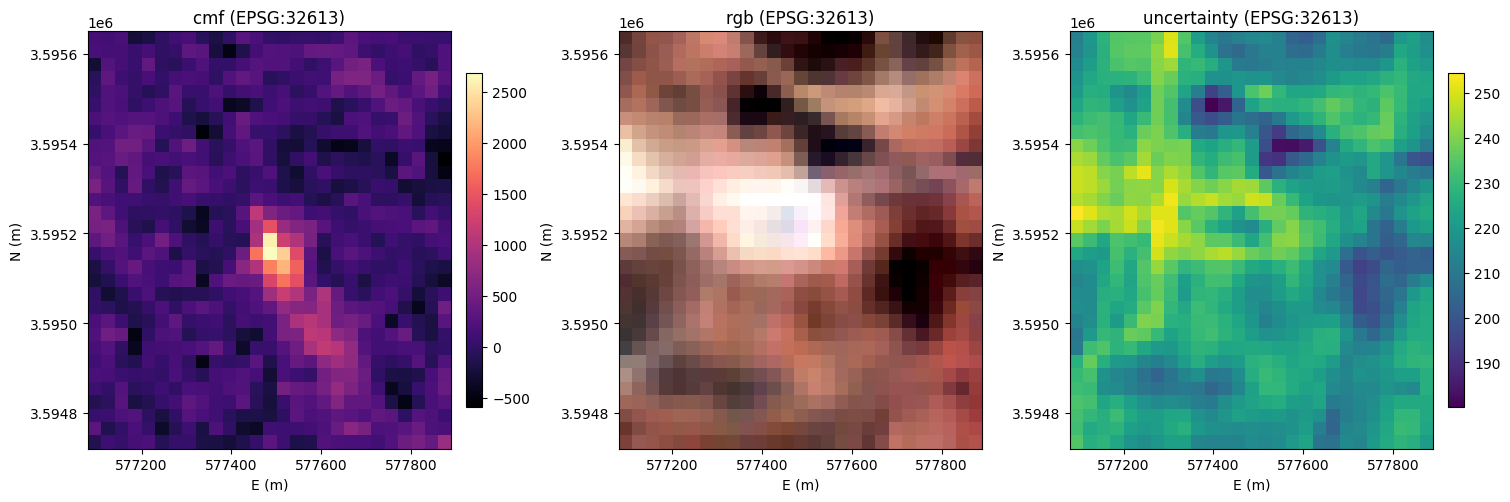

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import shapely.affinity as saff

# 4× pad the plume bounds for context before cropping.
context = saff.scale(box(*plume_bounds), xfact=4.0, yfact=4.0)
context_crops = ir.read_polygon(
    polygon=context, bands=("cmf", "rgb", "uncertainty"),
)

panels = [("cmf", "magma"), ("rgb", None), ("uncertainty", "viridis")]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), constrained_layout=True)
for ax, (band, cmap) in zip(axes, panels):
    reader = context_crops[band]
    if reader is None:
        ax.set_axis_off()
        ax.set_title(f"{band} (no overlap)")
        continue
    geo = reader.load()
    arr = np.asarray(geo.values)
    bx = geo.bounds

    if band == "rgb" and arr.ndim == 3 and arr.shape[0] >= 3:
        img = np.moveaxis(arr[:3], 0, -1).astype("float32")
        lo, hi = np.nanpercentile(img, [2, 98])
        img = np.clip((img - lo) / max(hi - lo, 1e-9), 0, 1)
        ax.imshow(img, extent=(bx[0], bx[2], bx[1], bx[3]), origin="upper")
    else:
        a = arr.squeeze().astype("float32")
        nd = reader.nodata
        if nd is not None:
            a = np.where(a == nd, np.nan, a)
        im = ax.imshow(
            a, extent=(bx[0], bx[2], bx[1], bx[3]),
            origin="upper", cmap=cmap,
        )
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"{band} ({geo.crs})")
    ax.set_xlabel("E (m)")
    ax.set_ylabel("N (m)")
    ax.set_aspect("equal")
plt.show()

## 2 · `CMPlumeRaster` — L3A per-plume mask

Wraps only the L3A `plume_tif` GeoTIFF (and optional
`ime_outline_geojson`). All PNG and `con_tif` URLs are dropped at
construction so the wrapper's surface is exactly the GeoTIFF +
polygon-extraction primitives.

Build via `from_cmrawplume(plume)` (typed plume → raster) or
directly from a response dict with `from_plume_dict(...)`.

In [7]:
pr = CMPlumeRaster.from_cmrawplume(plume)
print(f"plume_id          : {pr.plume_id}")
print(f"urls (filtered)   : {list(pr.urls)}")
print(f"plume_tif reader  : {type(pr.plume_tif).__name__}")

plume_id          : tan20251212t185057c20s4001-E
urls (filtered)   : ['plume_tif']
plume_tif reader  : RasterioReader


### `load_alpha_mask` — boolean band-4 alpha

The fourth band of `plume_tif` is the binary plume alpha mask.
`load_alpha_mask` returns a boolean `GeoTensor` aligned with the
raster grid.

In [8]:
mask = pr.load_alpha_mask()
if mask is None:
    print("plume_tif unavailable")
else:
    print(f"alpha shape : {mask.values.shape}")
    n_plume = int(np.asarray(mask.values).sum())
    n_total = int(np.asarray(mask.values).size)
    print(f"plume pixels: {n_plume:,} of {n_total:,} ({100 * n_plume / n_total:.1f}%)")

alpha shape : (101, 100)
plume pixels: 730 of 10,100 (7.2%)


### Visualise the alpha mask

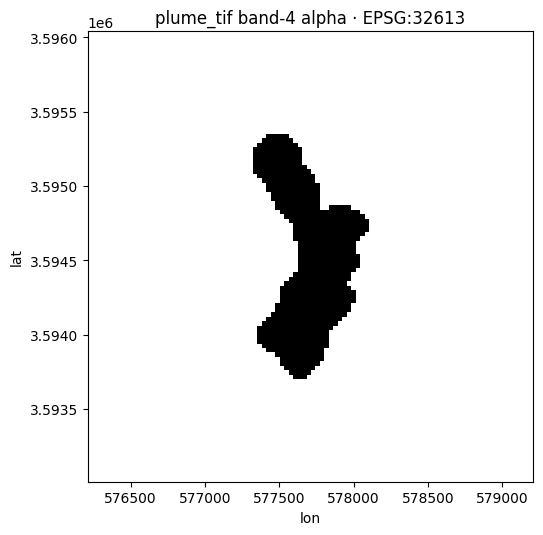

In [9]:
if mask is not None:
    bx = mask.bounds
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.imshow(
        np.asarray(mask.values),
        extent=(bx[0], bx[2], bx[1], bx[3]),
        origin="upper", cmap="Greys", interpolation="nearest",
    )
    ax.set_title(f"plume_tif band-4 alpha · {mask.crs}")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    plt.tight_layout()
    plt.show()

### `polygon()` — best-available plume outline

Prefers `ime_outline_geojson` when present (no rasterio); falls
back to vectorising the band-4 alpha mask
(`polygon_from_alpha`).

For a `CMRawPlume` built from `/catalog/plume/{id}` no outline URL
is returned, so this falls through to alpha extraction.

In [10]:
poly = pr.polygon()
if poly is None:
    print("no polygon available")
else:
    print(f"polygon bounds       : {poly.bounds}")
    print(f"polygon area (deg²)  : {poly.area:.6e}")

polygon bounds       : (-104.17701473305834, 32.4778075938023, -104.16873813434665, 32.49270973590736)
polygon area (deg²)  : 6.307290e-05


### Polygon overlay on the L2B products

Reproject the extracted plume polygon (EPSG:4326) into the scene
CRS and overlay on the wider crop — verifies the mask aligns with
the methane signal.

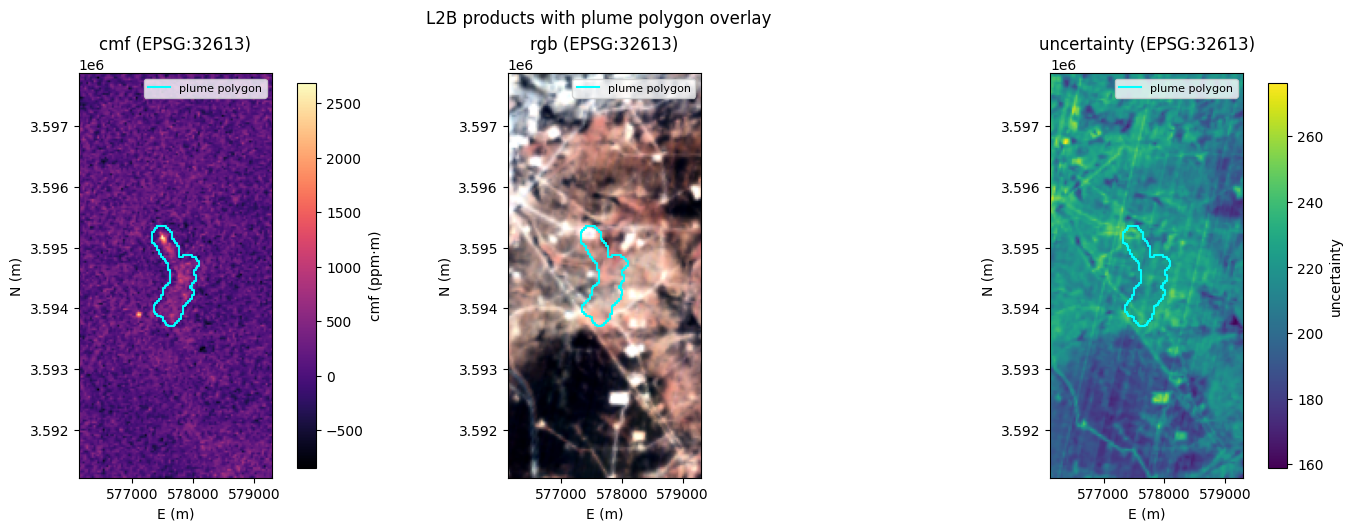

In [11]:
from georeader import window_utils

# Re-crop fresh against the polygon's bounds (4× padded) so the figure
# extent fully encloses the polygon, then overlay it on each band.
overlay_window = saff.scale(box(*poly.bounds), xfact=4.0, yfact=4.0)
overlay_crops = ir.read_polygon(
    polygon=overlay_window, bands=("cmf", "rgb", "uncertainty"),
)

panels = [
    ("cmf",         "magma",   "cmf (ppm·m)"),
    ("rgb",         None,      None),
    ("uncertainty", "viridis", "uncertainty"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), constrained_layout=True)
for ax, (band, cmap, cbar_label) in zip(axes, panels):
    reader = overlay_crops[band]
    if reader is None:
        ax.set_axis_off()
        ax.set_title(f"{band} (no overlap)")
        continue
    geo = reader.load()
    arr = np.asarray(geo.values)
    bx = geo.bounds

    if band == "rgb" and arr.ndim == 3 and arr.shape[0] >= 3:
        img = np.moveaxis(arr[:3], 0, -1).astype("float32")
        lo, hi = np.nanpercentile(img, [2, 98])
        img = np.clip((img - lo) / max(hi - lo, 1e-9), 0, 1)
        ax.imshow(img, extent=(bx[0], bx[2], bx[1], bx[3]), origin="upper")
    else:
        a = arr.squeeze().astype("float32")
        nd = reader.nodata
        if nd is not None:
            a = np.where(a == nd, np.nan, a)
        im = ax.imshow(
            a, extent=(bx[0], bx[2], bx[1], bx[3]),
            origin="upper", cmap=cmap,
        )
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)

    # Reproject the polygon into this band's CRS and overlay.
    poly_scene = window_utils.polygon_to_crs(
        poly, crs_polygon="EPSG:4326", dst_crs=str(geo.crs),
    )
    geoms = (
        poly_scene.geoms if poly_scene.geom_type == "MultiPolygon"
        else [poly_scene]
    )
    plotted = False
    for g in geoms:
        x, y = g.exterior.xy
        ax.plot(
            x, y, color="cyan", linewidth=1.5,
            label="plume polygon" if not plotted else None,
        )
        plotted = True
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(f"{band} ({geo.crs})")
    ax.set_xlabel("E (m)")
    ax.set_ylabel("N (m)")
    ax.set_aspect("equal")

fig.suptitle("L2B products with plume polygon overlay")
plt.show()

## 3 · `from_plume_dict` — defensive key filtering

Demonstrates that PNG / `con_tif` keys present on a raw API
response are stripped at construction — only `plume_tif` (and
optional `ime_outline_geojson`) survive on `urls`.

In [12]:
messy = {
    "plume_id": "tan-demo-A",
    "plume_tif": "https://x/plume.tif",
    "con_tif": "https://x/con.tif",          # dropped
    "rgb_png": "https://x/rgb.png",          # dropped
    "plume_png": "https://x/plume.png",      # dropped
    "plume_rgb_png": "https://x/rgbp.png",   # dropped
    "rgb_tif": None,                         # dropped (None)
}
demo = CMPlumeRaster.from_plume_dict(messy)
print(f"surviving urls: {list(demo.urls)}")

surviving urls: ['plume_tif']


## See also

- [`api_explore.ipynb`](api_explore.ipynb) — the typed query layer
  that produces the `CMRawPlume` / `CMTileItem` instances consumed
  here.
- [Carbon Mapper Reader API reference](../modules/readers_module.md#carbon-mapper-reader)
  — full module / class / function listing rendered from
  source.
- [GeoReader concepts](../modules/read_module.md) — the abstract
  `GeoData` protocol both `RasterioReader` and `GeoTensor` satisfy.
